# The Setup & Creating the "Image"

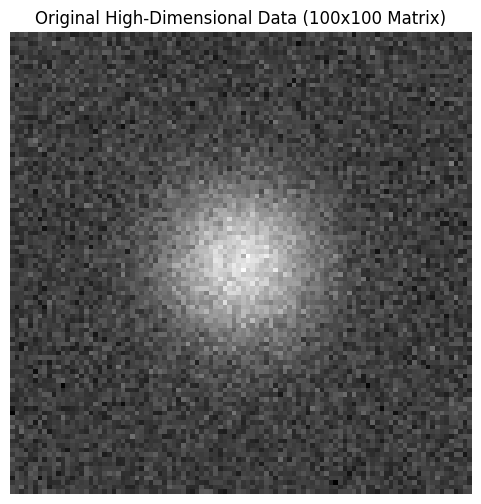

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a synthetic image (A 2D Gaussian "Signal")
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
clean_signal = np.exp(-(X**2 + Y**2))

# 2. Add random noise to simulate messy, real-world data
np.random.seed(42)
noise = np.random.normal(0, 0.1, clean_signal.shape)
messy_image = clean_signal + noise

# Display the noisy image
plt.figure(figsize=(6, 6))
plt.imshow(messy_image, cmap='gray')
plt.title("Original High-Dimensional Data (100x100 Matrix)")
plt.axis('off')
plt.show()

## Performing SVD ($A = U \Sigma V^T$)

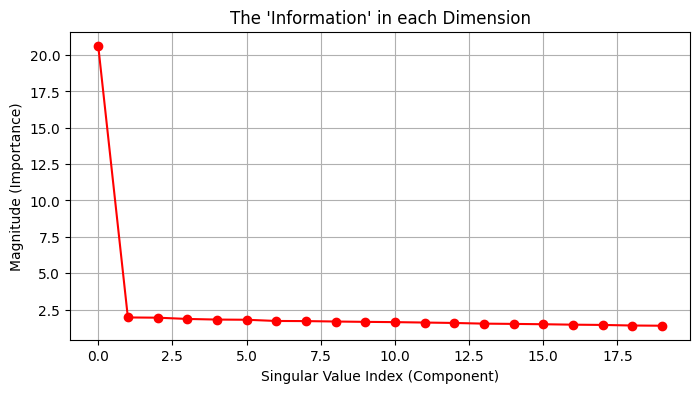

Notice how the first few components hold massive value,
while the rest drop near zero. Those trailing numbers are just noise!


In [2]:
# Perform Singular Value Decomposition
U, S, Vt = np.linalg.svd(messy_image, full_matrices=False)

# Plot the Singular Values (The "Scree Plot")
plt.figure(figsize=(8, 4))
plt.plot(S[:20], marker='o', color='red')
plt.title("The 'Information' in each Dimension")
plt.xlabel("Singular Value Index (Component)")
plt.ylabel("Magnitude (Importance)")
plt.grid(True)
plt.show()

print("Notice how the first few components hold massive value,")
print("while the rest drop near zero. Those trailing numbers are just noise!")

## Compressing the World

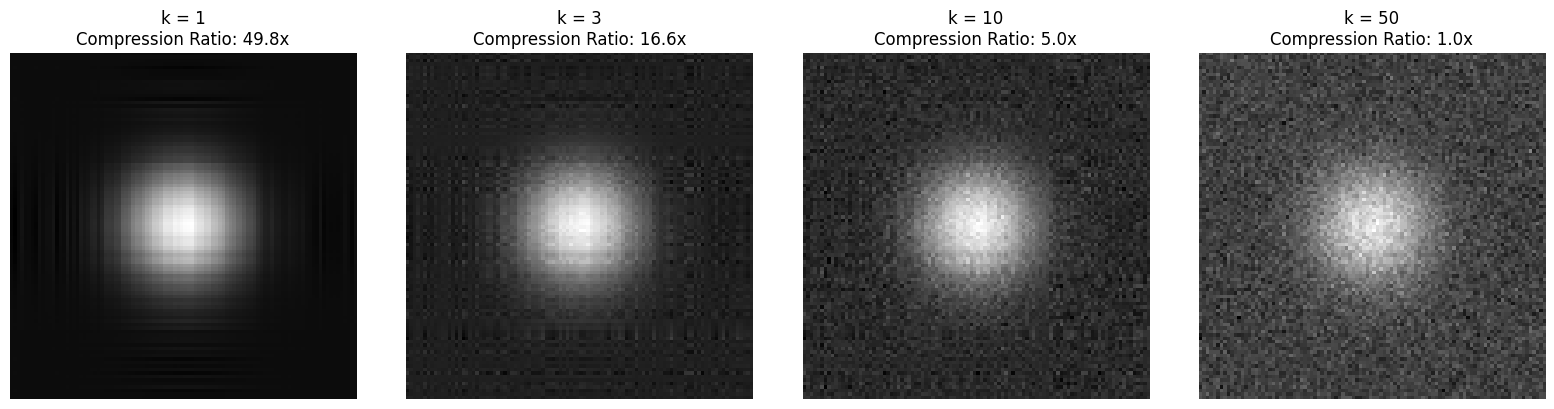

In [3]:
def reconstruct_image(U, S, Vt, k):
    """Reconstructs the matrix using only the top 'k' singular values."""
    # U[:, :k] @ diag(S[:k]) @ Vt[:k, :]
    compressed = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    return compressed

# Create side-by-side comparisons
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Different levels of compression
k_values = [1, 3, 10, 50]

for i, k in enumerate(k_values):
    compressed_img = reconstruct_image(U, S, Vt, k)
    axes[i].imshow(compressed_img, cmap='gray')

    # Calculate compression ratio
    original_size = 100 * 100
    compressed_size = (100 * k) + k + (k * 100)
    ratio = original_size / compressed_size

    axes[i].set_title(f"k = {k}\nCompression Ratio: {ratio:.1f}x")
    axes[i].axis('off')

plt.tight_layout()
plt.show()